In [2]:
# ====== 依赖 ======
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import lstsq, eig
from scipy.signal import welch

# ====== 1) 准备 hidden state 并做低维投影 ======
def to_2d_time_first(h):
    # h: [T,D] or [B,T,D] -> [T,D]
    if h.ndim == 3:
        h = h.mean(axis=0)  # 批次平均，或改成某个样本
    return h  # [T,D]

def linear_project(h, d_latent=3):
    # 简单PCA（SVD）做线性瓶颈：h->[T,d_latent] 作为 z_t
    H = h - h.mean(0, keepdims=True)
    U, S, Vt = np.linalg.svd(H, full_matrices=False)
    W = Vt[:d_latent].T                     # [D, d_latent]
    z = H @ W                               # [T, d_latent]
    return z, W

# ====== 2) 估计一阶线性动力学 z_{t+1} ≈ A z_t ======
def estimate_A(z):
    Zt   = z[:-1]            # [T-1, d]
    Ztp1 = z[ 1:]            # [T-1, d]
    A, _, _, _ = lstsq(Zt, Ztp1, rcond=None)  # solve Zt @ A = Ztp1
    A = A.T                                  # [d,d]
    return A

# ====== 3) 可视化函数 ======

def plot_phase_traj(z):
    # 相图(前两维)，颜色随时间
    t = np.arange(len(z))
    plt.figure(figsize=(5,4))
    sc = plt.scatter(z[:,0], z[:,1], c=t, s=6)
    plt.xlabel('z1'); plt.ylabel('z2'); plt.title('Phase Portrait (z1 vs z2)')
    plt.colorbar(sc, label='time')
    plt.tight_layout(); plt.show()

def plot_3d_traj(z):
    if z.shape[1] < 3: return
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    t = np.arange(len(z))
    fig = plt.figure(figsize=(6,5))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(z[:,0], z[:,1], z[:,2], c=t, s=5)
    ax.set_xlabel('z1'); ax.set_ylabel('z2'); ax.set_zlabel('z3')
    ax.set_title('3D Latent Trajectory')
    plt.tight_layout(); plt.show()

def plot_autocorr(z, max_lag=200):
    # 维度平均的自相关（也可画成热力图）
    zc = z - z.mean(0, keepdims=True)
    ac = []
    for lag in range(max_lag+1):
        num = (zc[:-lag or None] * zc[lag:]).mean() if lag>0 else (zc*zc).mean()
        den = (zc*zc).mean()
        ac.append(num/den)
    ac = np.array(ac)
    plt.figure(figsize=(5,3))
    plt.plot(np.arange(max_lag+1), ac)
    plt.xlabel('lag'); plt.ylabel('autocorr'); plt.title('Mean Autocorrelation of z')
    plt.tight_layout(); plt.show()

def plot_psd(z, fs=200, nperseg=512):
    # 取前K维平均的功率谱
    K = min(5, z.shape[1])
    f, Pxx = welch(z[:,:K], fs=fs, nperseg=nperseg, axis=0)
    Pmean = Pxx.mean(axis=1)
    plt.figure(figsize=(5,3))
    plt.semilogy(f, Pmean)
    plt.xlabel('Hz'); plt.ylabel('PSD'); plt.title('Latent PSD (mean of first {} dims)'.format(K))
    plt.tight_layout(); plt.show()

def plot_poles(A, fs=200):
    # 极点图：单位圆 + A 特征值（离散极点）
    w, _ = eig(A)  # 复数
    plt.figure(figsize=(4,4))
    theta = np.linspace(0, 2*np.pi, 512)
    plt.plot(np.cos(theta), np.sin(theta))  # 单位圆
    plt.scatter(w.real, w.imag, s=30)
    plt.gca().set_aspect('equal', 'box')
    plt.title('Poles of A (discrete)')
    plt.xlabel('Re'); plt.ylabel('Im')
    plt.tight_layout(); plt.show()

    # 可选：把极点角频率映射到Hz： f = angle(w)*fs/(2π)
    f = np.angle(w) * fs / (2*np.pi)
    plt.figure(figsize=(5,3))
    plt.hist(np.abs(f), bins=30)
    plt.xlabel('Hz (|angle| mapped)'); plt.ylabel('count'); plt.title('Pole pseudo-frequencies')
    plt.tight_layout(); plt.show()

def plot_recurrence(z, k=2, thresh=None):
    # 复现图：时刻间两两距离
    Z = z[:,:k]  # 用前k维
    D = np.linalg.norm(Z[:,None,:] - Z[None,:,:], axis=-1)
    if thresh is not None:
        R = (D < thresh).astype(float)
        img = R
        title = 'Recurrence (thresholded)'
    else:
        img = D
        title = 'Recurrence (distance)'
    plt.figure(figsize=(4.5,4))
    plt.imshow(img, origin='lower', aspect='auto')
    plt.title(title); plt.xlabel('t'); plt.ylabel('t')
    plt.tight_layout(); plt.show()

def plot_free_rollout(z, A, steps=200):
    # 从某时刻起，用 A 自由滚动 vs 真值
    t0 = max(0, len(z)//3)
    z0 = z[t0]
    traj = [z0]
    for _ in range(steps-1):
        traj.append(traj[-1] @ A.T)
    traj = np.stack(traj, axis=0)  # [steps, d]
    t1 = min(t0+steps, len(z))
    ref = z[t0:t1]
    m = min(ref.shape[0], traj.shape[0])
    err = np.mean((ref[:m]-traj[:m])**2, axis=1)

    plt.figure(figsize=(5,3))
    plt.plot(err)
    plt.xlabel('step'); plt.ylabel('MSE'); plt.title('Free-rollout error (z via A)')
    plt.tight_layout(); plt.show()

    if z.shape[1] >= 2:
        plt.figure(figsize=(5,4))
        plt.plot(ref[:m,0], ref[:m,1], label='true')
        plt.plot(traj[:m,0], traj[:m,1], linestyle='--', label='rollout')
        plt.legend(); plt.xlabel('z1'); plt.ylabel('z2'); plt.title('Rollout vs True (phase)')
        plt.tight_layout(); plt.show()

# ====== 4) 一键跑全部可视化 ======
def visualize_latent_dynamics(h, fs=200, d_latent=3):
    h = to_2d_time_first(h)           # [T,D]
    z, W = linear_project(h, d_latent)
    A = estimate_A(z)

    plot_phase_traj(z)
    plot_3d_traj(z)
    plot_autocorr(z, max_lag=min(5_000, len(z)//3))
    plot_psd(z, fs=fs, nperseg=min(1024, len(z)))
    plot_poles(A, fs=fs)
    plot_recurrence(z, k=min(3, z.shape[1]), thresh=None)   # 或给阈值看看周期性
    plot_free_rollout(z, A, steps=min(500, len(z)//2))

# ====== 示例 ======
# 假设你已有 h: np.ndarray or torch.Tensor 形状 [B,T,D] 或 [T,D]
h = np.load('/mnt/dataset0/lzs/ccep_surrogate/new_lemon/lemon_032304/stc_0.npy').T
# visualize_latent_dynamics(h, fs=200, d_latent=3)


Internal font name = Arial


/home/lzs/miniconda3/envs/lzs/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36724 (\N{CJK UNIFIED IDEOGRAPH-8F74}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


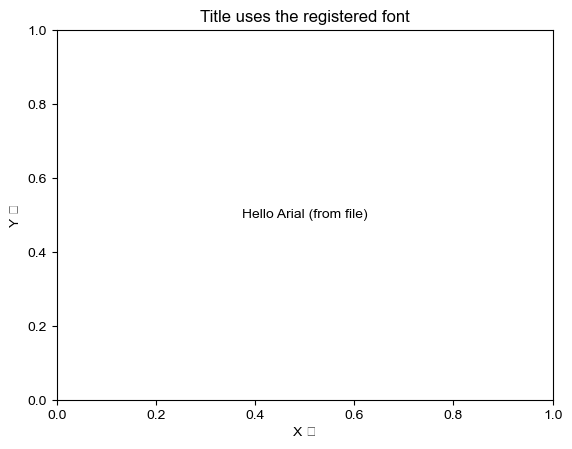

In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import os

font_path = '/mnt/dataset0/lzs/.fonts/arial.ttf'  # 1) 路径要确认存在
assert os.path.exists(font_path), f"字体文件不存在: {font_path}"

# 2) 注册字体到 Matplotlib 的 fontManager（关键！）
fm.fontManager.addfont(font_path)

# 3) 读取这份 ttf 的“内部字体名”（可能是 Arial / ArialMT 等）
font_name = fm.FontProperties(fname=font_path).get_name()
print("Internal font name =", font_name)

# 4) 彻底避免去找 'Arial' 这个字符串
mpl.rcParams['font.family'] = [font_name]       # 用内部名
mpl.rcParams['font.sans-serif'] = [font_name]   # 避免回退到其他 sans-serif
mpl.rcParams['axes.unicode_minus'] = False

# （可选）如果你曾经设置过 'Arial'，先清理干净：
# mpl.rcParams['font.family'] = 'sans-serif'
# mpl.rcParams['font.sans-serif'] = [font_name]

# 5) 画个图测试（坐标轴/标题/文字都应使用该字体，不再报错）
plt.figure()
plt.title('Title uses the registered font')
plt.xlabel('X 轴')
plt.ylabel('Y 轴')
plt.text(0.5, 0.5, 'Hello Arial (from file)', ha='center', va='center')
plt.show()


In [4]:
import pandas as pd
import os
import random
import requests
import json
import numpy as np
from urllib3.util.retry import Retry
import openai
from requests.adapters import HTTPAdapter
import os
import pickle
import matplotlib.pyplot as plt
# from utils.read_group_danmu import read_group_danmu

/home/lzs/miniconda3/envs/lzs/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (1.26.15) or chardet (7.3.0)/charset_normalizer (3.4.1) doesn't match a supported version!
  warnings.warn(


In [5]:
labels = np.array(['Happiness', 'Surprise', 'Sadness', 'Anger', 'Disgust', 'Fear'])
indices_name = ['Inertia', 'Instability', 'Average controllability', 'Modal controllability']

In [6]:
import pandas as pd
import pickle
with open(r'/mnt/dataset1/xinke/Danmu/DyEmo-film/Emotion_scores/scores_allMovies_resample.pkl', 'rb') as f:
    scores_dict = pickle.load(f)
keys = list(scores_dict.keys())
file_path = r'/mnt/dataset1/xinke/Danmu/DyEmo-film/movie_info_final3.CSV'  # 替换为你的文件路径

# 读取 Excel 文件
df = pd.read_csv(file_path)
eng_names = df['English Name'].astype(str).tolist()  # 确保转换为字符串类型
eng_names = [eng_names[i][1:] for i in range(len(eng_names))]
bvids = df['BVID'].astype(str).tolist()  # 确保转换为字符串类型
chi_names = df['Chinese Name'].astype(str).tolist() 

import copy
movie_names = copy.deepcopy(keys)
for i in range(len(keys)):
    for j in range(len(bvids)):
        if bvids[j] == keys[i]:
            movie_names[i] = chi_names[j]
movie_names = [movie_names[i] for i in range(len(movie_names)) if i not in [50,99,102]]
print(movie_names)

movie_names_eng = [
    "Batman Dark Knight",
    "Be Somebody",
    "Forrest Gump",
    "Big World Gashapon",
    "Godzilla",
    "Green Book",
    "Harry Potter and the Goblet of Fire",
    "Heidi",
    "Kung Fu",
    "Let the Bullets Fly",
    "The Legend of Luo Xiaohei",
    "The Bad Guys",
    "The Shawshank Redemption",
    "The Wandering Earth II",
    "Weathering With You",
    "White Snake",
    "World War Z",
    "Yang Jian",
    "Suzume",  # 铃芽之旅
    "Johnny Keep Walking!",  # 年会不能停!
    "The Lord of the Rings: The Fellowship of the Ring",  # 指环王1
    "The SpongeBob SquarePants Movie",  # 海绵宝宝历险记
    "Our Fathers",  # 我们的父辈
    "Detective Conan: The Phantom of Baker Street",  # 名侦探柯南
    "Love Letter",  # 情书
    "Harry Potter and the Order of the Phoenix",
    "Detective Conan: The Bride of Halloween",
    "White Snake 2: The Tribulation of Green Snake",
    "New Gods: Nezha Reborn",
    "The Truman Show",  # 楚门的世界
    "Transformers",
    "Flipped",  # 怦然心动
    "The Pig, the Snake and the Pigeon",  # 周处除三害
    "Date A Live Movie: Mayuri Judgment",
    "Rascal Does Not Dream of a Dreaming Girl",
    "Violet Evergarden: The Movie",
    "Journey to the West",  # 宇宙探索编辑部
    "Sword Art Online: Ordinal Scale",  # 刀剑神域
    "Overlord: The Dark Hero",
    "Rurouni Kenshin",  # 浪客剑心
    "A Silent Voice",  # 声之形
    "Harry Potter and the Half-Blood Prince",
    "Harry Potter and the Chamber of Secrets",
    "Still Miss You",  # 还是觉得你最好
    "Ready Player One",  # 头号玩家
    "Edge of Tomorrow",  # 明日边缘
    "Transformers: Revenge of the Fallen",
    "Fate/stay night: Heaven's Feel I. presage flower",
    "Fantastic Beasts and Where to Find Them",
    "Harry Potter and the Sorcerer's Stone",
    "Promare",  # 普罗米亚
    "Fireworks",  # 烟花
    "Goodbye Mr. Loser",  # 夏洛特烦恼
    "Tamako Love Story",  # 玉子爱情故事
    "Leap",  # 夺冠
    "A Little Thing Called Love",  # 初恋这件小事
    "The Legend of Sealed Book",  # 天书奇谭
    "The SpongeBob Movie: Sponge Out of Water",  # 海绵宝宝水兵陆战队
    "The Garden of Words",  # 言叶之庭
    "Kowloon Walled City",  # 九龙城寨
    "The Silence of the Lambs",
    "Inception",  # 盗梦空间
    "Interstellar",
    "Deep Sea",  # 深海
    "Jiang Ziya",  # 姜子牙
    "Harry Potter and the Deathly Hallows Part 2",
    "CJ7",  # 长江七号
    "Lost on Journey",  # 人在囧途
    "Only Fools Rush In",  # 四海
    "Five Hundred Miles",  # 交换人生
    "The Godfather",
    "Harry Potter and the Prisoner of Azkaban",
    "Minions",  # 小黄人大眼萌
    "Violet Evergarden: Eternity and the Auto Memories Doll",
    "One Second",  # 一秒钟
    "Sword Art Online Progressive: Aria of a Starless Night",
    "Catch Me If You Can",  # 猫鼠游戏
    "Wolf Warrior",  # 战狼
    "Brotherhood of Blades",  # 绣春刀
    "Hidden Blade",  # 无名
    "Endless Journey",  # 三大队
    "Pegasus 2",  # 飞驰人生2
    "Evangelion: 2.22 You Can (Not) Advance",
    "Evangelion: 3.33 You Can (Not) Redo",
    "Evangelion: 1.11 You Are (Not) Alone",
    "Evangelion: Death and Rebirth",
    "Crazy Racer",  # 疯狂的赛车
    "My Little Pony Equestria Girls: Friendship Games",  # 彩虹小马
    "My Own Swordsman",  # 武林外传
    "Words Bubble Up Like Soda Pop",  # 言语如苏打般涌现
    "No Time to Die",  # 007
    "Overlord: The Undead King",
    "5 Centimeters Per Second",  # 秒速5厘米
    "Win the Kids",  # 抓娃娃
    "The Founding of a Republic",  # 建国大业
    "Ip Man",  # 叶问
    "The King's Avatar: For the Glory",  # 全职高手
    "Shin Ultraman",  # 新·奥特曼
    "Pleasant Goat and Big Big Wolf: Dunk for Future",  # 喜羊羊
    "One Piece Film: Red",  # 航海王
    "Johnny English",  # 憨豆特工
    "Pacific Rim"  # 环太平洋
]

movie_names_eng = [movie_names_eng[i] for i in range(len(movie_names_eng)) if i not in [50,99]]

['Batman_darknight', 'Be_somebody', 'forrest_gump', 'Gashapon', 'Godzilla', 'Green_book', 'Harry_potter', 'Heidi', 'Kong_fu', 'let_bullet_fly_reorder', 'Luo_xiao_hei', 'The_bad_guys', 'The_Shawshank_Redemption', 'The_Wandering_Earth_II', 'Weathering_With_You', 'White_snake', 'World_War_Z', 'Yang_jian', '铃芽之旅', '年会不能停！', '指环王1：护戒使者', '海绵宝宝历险记', '我们的父辈', '名侦探柯南：贝克街的亡灵', '情书', '哈利·波特与凤凰社', '名侦探柯南：万圣节的新娘', '白蛇2：青蛇劫起', '新神榜：哪吒重生', '楚门的世界', '变形金刚', '怦然心动', '周处除三害', '约会大作战 万由里裁决', '青春猪头少年不会梦到怀梦美少女', '紫罗兰永恒花园剧场版', '宇宙探索编辑部', '刀剑神域：序列之争', '不死者之王：漆黑的英雄', '浪客剑心', '声之形', '哈利·波特与混血王子', '哈利·波特与密室', '还是觉得你最好', '头号玩家', '明日边缘', '变形金刚2：堕落者的复仇', '命运之夜——天之杯：恶兆之花', '神奇动物在哪里', '哈利·波特与魔法石', '烟花', '夏洛特烦恼', '玉子爱情故事', '夺冠', '初恋这件小事', '天书奇谭', '海绵宝宝历险记', '言叶之庭', '九龙城寨', '沉默的羔羊', '盗梦空间', '星际穿越', '深海', '姜子牙', '哈利·波特与死亡圣器（下）', '长江七号', '人在囧途', '四海', '交换人生', '教父', '哈利·波特与阿兹卡班的囚徒', '小黄人大眼萌', '紫罗兰永恒花园 外传：永远与自动手记人偶', '一秒钟', '刀剑神域进击篇:无星之夜', '猫鼠游戏', '战狼', '绣春刀', '无名', '三大队', '飞驰人生2', '福音战士新剧场版：破', '福音战士新剧场版：Q', 'EVA新世纪福音战士

In [7]:
MC_all = np.load('/mnt/dataset1/xinke/Danmu/Code/Reproduce_figures/results/MC_all.npy')
AC_all = np.load('/mnt/dataset1/xinke/Danmu/Code/Reproduce_figures/results/AC_all.npy')
instability_all = np.load('/mnt/dataset1/xinke/Danmu/Code/Reproduce_figures/results/instability_all.npy')
lambda_movies = np.load('/mnt/dataset1/xinke/Danmu/Code/Reproduce_figures/results/lambda_movies.npy')
print(AC_all.shape, MC_all.shape, instability_all.shape, lambda_movies.shape)

(102, 6) (102, 6) (102, 6) (102, 6)


In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 标准化数据（使各特征均值为0，标准差为1）
scaler = StandardScaler()
lambda_scaled = scaler.fit_transform(-lambda_movies[np.concatenate((np.arange(50), np.arange(51,99), np.arange(100,102))),:])

scaler = StandardScaler()
instability_scaled = scaler.fit_transform(instability_all[np.concatenate((np.arange(50), np.arange(51,99), np.arange(100,102))),:])

scaler = StandardScaler()
AC_scaled = scaler.fit_transform(AC_all[np.concatenate((np.arange(50), np.arange(51,99), np.arange(100,102))),:])

scaler = StandardScaler()
MC_scaled = scaler.fit_transform(MC_all[np.concatenate((np.arange(50), np.arange(51,99), np.arange(100,102))),:])

pca = PCA(n_components=12)
data_concat = np.concatenate(( lambda_scaled,instability_scaled,AC_scaled, MC_scaled, ),1)
pca.fit(data_concat)
print(pca.explained_variance_ratio_)

[0.26979931 0.17179377 0.10986462 0.09551551 0.07719848 0.0518065
 0.04194603 0.03460646 0.02527372 0.02406411 0.01986977 0.01423233]


In [9]:
labels = np.array(['Happiness', 'Surprise', 'Sadness', 'Anger', 'Disgust', 'Fear'])
indices_name = ['Average controllability', 'Modal controllability', 'Instability', 'Inertia']

In [10]:
from sklearn.manifold import TSNE
X_embedded = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=3,random_state=42).fit_transform(data_concat)

In [11]:
from sklearn.manifold import TSNE
X_embedded = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=2,random_state=0).fit_transform(data_concat)

In [12]:
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

n_clusters = 6

Z = linkage(X_embedded, method='ward')

cluster_ids = fcluster(
    Z,
    t=n_clusters,
    criterion='maxclust'
)

# 找一个对应 n_clusters 的 dendrogram 颜色阈值
# Z[:, 2] 是每次合并的距离，高度从小到大排列
# 要得到 k 个簇，需要切在第 n-k 次合并和第 n-k+1 次合并之间
n_samples = X_embedded.shape[0]
merge_heights = Z[:, 2]

lower = merge_heights[n_samples - n_clusters - 1]
upper = merge_heights[n_samples - n_clusters]

color_threshold = (lower + upper) / 2

print("color_threshold for 6 clusters:", color_threshold)
print("number of clusters:", len(np.unique(cluster_ids)))

color_threshold for 6 clusters: 94.06802853448328
number of clusters: 6


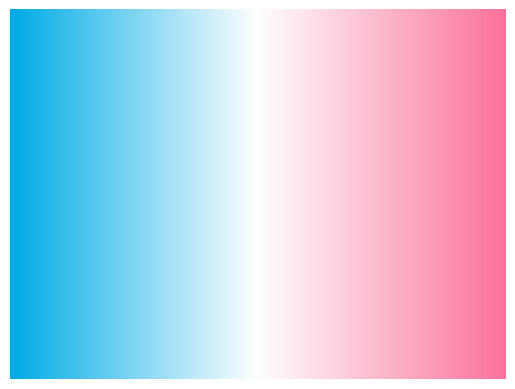

In [14]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# 定义RGB（0-1范围）
white = (1, 1, 1)
pink = (251/255*0.8, 114/255*0.8, 153/255*0.8)
blue = (0/255, 171/255*0.8, 229/255*0.8)
pink = (251/255, 114/255, 153/255)
blue = (0/255, 171/255, 229/255)
# 创建从 pink → white → blue 的 colormap
bilibili_cmap = LinearSegmentedColormap.from_list(
    "bilibili_pinkblue",
    [blue, white, pink]
)

# 注册
#plt.register_cmap(cmap=bilibili_cmap)

# 可视化测试
plt.imshow([list(range(256))], cmap=bilibili_cmap, aspect='auto')
plt.axis("off")
plt.show()


/tmp/ipykernel_1898569/114866494.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(labels.tolist()*4, rotation=90, fontsize=11)
/tmp/ipykernel_1898569/114866494.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


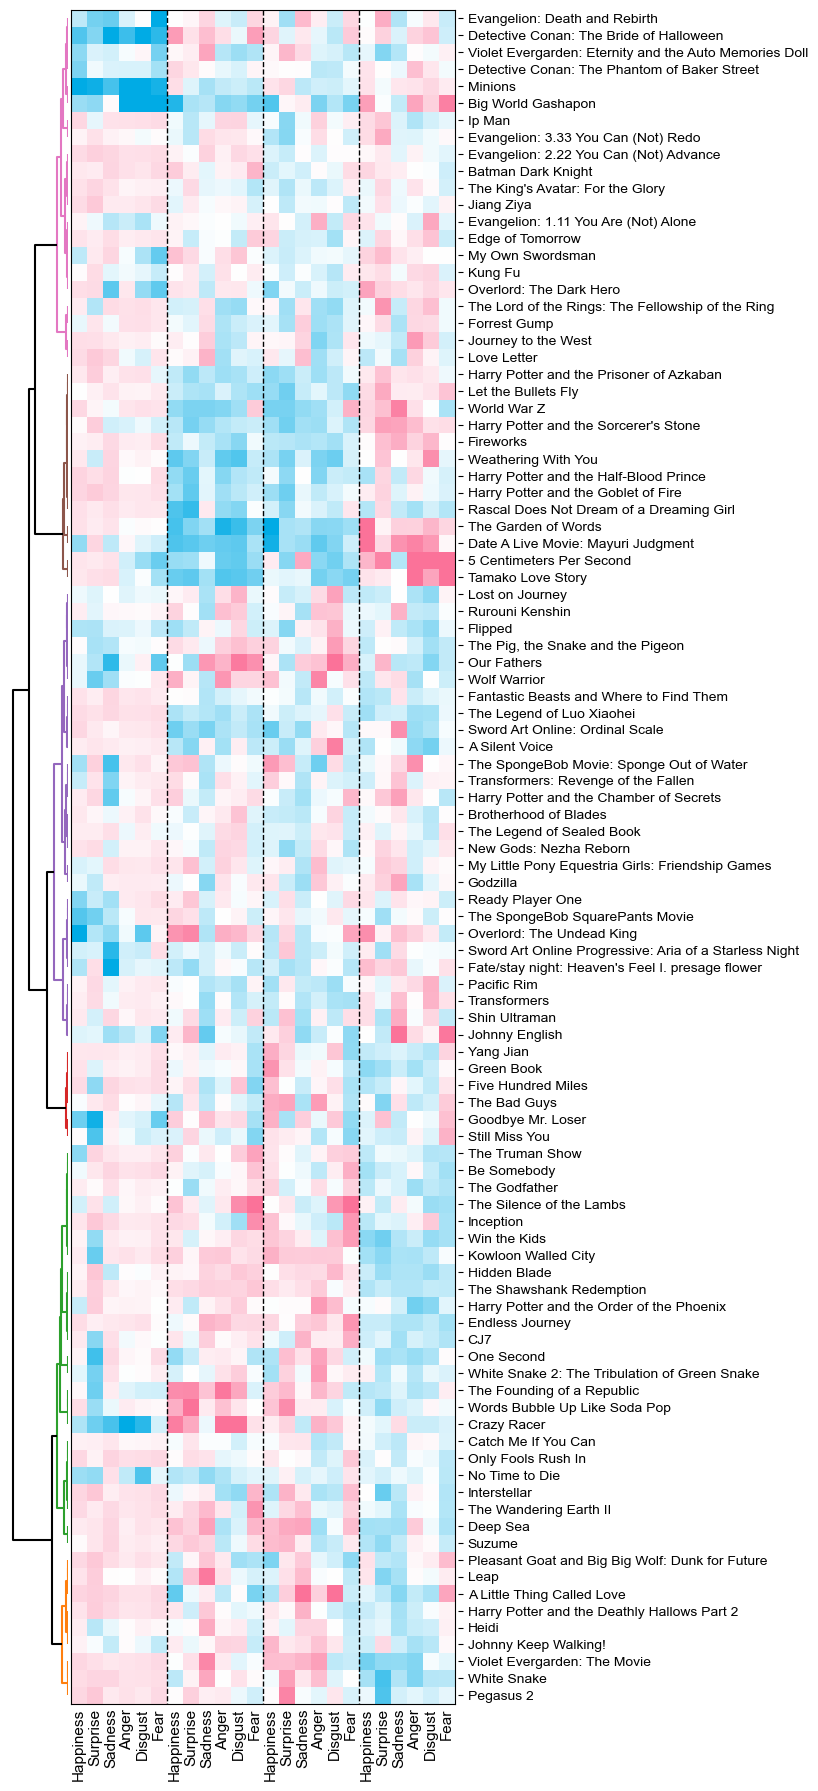

总簇数: 6

Cluster 1 | color=C1 | size=9
  - Heidi
  - White Snake
  - Johnny Keep Walking!
  - Violet Evergarden: The Movie
  - Leap
  - A Little Thing Called Love
  - Harry Potter and the Deathly Hallows Part 2
  - Pegasus 2
  - Pleasant Goat and Big Big Wolf: Dunk for Future

Cluster 2 | color=C2 | size=24
  - Be Somebody
  - The Shawshank Redemption
  - The Wandering Earth II
  - Suzume
  - Harry Potter and the Order of the Phoenix
  - White Snake 2: The Tribulation of Green Snake
  - The Truman Show
  - Kowloon Walled City
  - The Silence of the Lambs
  - Inception
  - Interstellar
  - Deep Sea
  - CJ7
  - Only Fools Rush In
  - The Godfather
  - One Second
  - Catch Me If You Can
  - Hidden Blade
  - Endless Journey
  - Crazy Racer
  - Words Bubble Up Like Soda Pop
  - No Time to Die
  - Win the Kids
  - The Founding of a Republic

Cluster 3 | color=C3 | size=6
  - Green Book
  - The Bad Guys
  - Yang Jian
  - Still Miss You
  - Goodbye Mr. Loser
  - Five Hundred Miles

Cluster 4 | 

In [15]:


# ------------- 绘图 -------------
fig = plt.figure(figsize=(5.78,22))
gs = gridspec.GridSpec(1, 3, width_ratios=[0.5, 3.3, 0], wspace=0.02)

# 中间热图（注意我按你的代码使用 data_concat，行顺序倒序显示）
ax0 = plt.subplot(gs[1])
im = ax0.imshow(data_concat[order[::-1]], cmap=bilibili_cmap,
                aspect='auto', vmin=-3, vmax=3)

# x 轴标签（每 6 列一个情绪）
ax0.set_xticklabels(labels.tolist()*4, rotation=90, fontsize=11)
ax0.tick_params(axis='x', length=0)
n_feats = data_concat.shape[1]
ax0.xaxis.set_major_locator(plt.FixedLocator(range(n_feats)))
ax0.plot([5.5,  5.5],  [-0.5, 99.5], 'k--', lw=1)
ax0.plot([11.5, 11.5], [-0.5, 99.5], 'k--', lw=1)
ax0.plot([17.5, 17.5], [-0.5, 99.5], 'k--', lw=1)
ax0.set_yticks([])
ax0.get_yaxis().set_visible(False)

# 左侧树（真正画出来，供视觉参照；颜色阈值一致）
ax1 = plt.subplot(gs[0])
dendro_draw = dendrogram(
    Z,
    orientation='left',
    color_threshold=color_threshold,
    above_threshold_color='black',
    no_labels=True,
    ax=ax1
)
ax1.set_xticks([]); ax1.set_yticks([]); ax1.set_frame_on(False)

# 右侧电影名（与叶子颜色一致）
ax2 = plt.subplot(gs[2], sharey=ax0)
ax2.set_yticks(range(len(order)))
names_right = [movie_names_eng[i] for i in order[::-1]]  # 右侧显示顺序与热图一致（倒序）
ax2.set_yticklabels(names_right, fontsize=10)
ax2.yaxis.tick_right()


ax2.yaxis.set_label_position('right')
for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.set_xticks([]); ax2.set_xticklabels([])

# 着色 ytick：根据“原叶子索引 -> 颜色”的映射
# 注意：ax2 的第 k 条 ytick 对应的是 order[::-1][k] 这个样本
for k, tick in enumerate(ax2.get_yticklabels()):
    leaf_idx = order[::-1][k]
    tick.set_color('black')
    # leaf_color_map.get(leaf_idx, 'black')
plt.tight_layout()
plt.savefig("movie_cluster.svg", bbox_inches="tight")
plt.show()

# ------------- 生成簇列表（每簇一个子 list） -------------
# 用 color_threshold 分簇（与树颜色阈值一致）
cluster_ids = fcluster(Z, t=color_threshold, criterion='distance')  # shape=(n_samples,)
# 可选：保持电影顺序或按簇分组
clusters = []
for cid in np.unique(cluster_ids):
    members_idx = np.where(cluster_ids == cid)[0]
    members_eng = [movie_names_eng[i] for i in members_idx]
    # 如有中文名：把它们拼成 (英文, 中文) 二元组
    # members = [(movie_names_eng[i], movie_names_cn[i]) for i in members_idx]
    clusters.append(members_eng)

# 如果想同时带上对应“树颜色”可做一个簇颜色表：
# 取该簇中第一个成员的叶子颜色（只是粗略代表）
cluster_colors = []
for cid in np.unique(cluster_ids):
    members_idx = np.where(cluster_ids == cid)[0]
    if len(members_idx) > 0:
        c0 = leaf_color_map.get(members_idx[0], 'black')
    else:
        c0 = 'black'
    cluster_colors.append(c0)

# 打印结果示例

print('总簇数:', len(clusters))
for idx, (c_members, c_color) in enumerate(zip(clusters, cluster_colors), 1):
    print(f'\nCluster {idx} | color={c_color} | size={len(c_members)}')
    for name in c_members:
        print('  -', name)
# 之后你就可以用 `clusters` 做每个簇的类型/题材分析啦


# 多次聚类

In [14]:

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import linkage, fcluster
from itertools import combinations


def run_tsne_hclust(
    X_raw,
    seed=0,
    n_clusters=4,
    perplexity=2,
    init="pca",
    scale=True,
):
    """
    返回：
    emb: t-SNE 二维坐标
    labels: 每个样本的聚类标签
    Z: linkage 结果
    """
    X = np.asarray(X_raw)

    if scale:
        X = StandardScaler().fit_transform(X)

    emb = TSNE(
        n_components=2,
        learning_rate="auto",
        init=init,
        perplexity=perplexity,
        random_state=seed,
    ).fit_transform(X)

    Z = linkage(emb, method="ward")
    labels = fcluster(Z, t=n_clusters, criterion="maxclust")

    return emb, labels, Z

In [15]:
def seed_stability_test(
    data_concat,
    seeds=range(50),
    n_clusters=4,
    perplexity=2,
    init="pca",
):
    all_labels = []
    all_embeddings = []

    for seed in seeds:
        emb, labels, Z = run_tsne_hclust(
            data_concat,
            seed=seed,
            n_clusters=n_clusters,
            perplexity=perplexity,
            init=init,
        )
        all_embeddings.append(emb)
        all_labels.append(labels)

    records = []
    for i, j in combinations(range(len(seeds)), 2):
        ari = adjusted_rand_score(all_labels[i], all_labels[j])
        nmi = normalized_mutual_info_score(all_labels[i], all_labels[j])
        records.append({
            "seed_i": seeds[i],
            "seed_j": seeds[j],
            "ARI": ari,
            "NMI": nmi,
        })

    result = pd.DataFrame(records)

    summary = result[["ARI", "NMI"]].agg(["mean", "std", "min", "median", "max"])

    return result, summary, all_labels, all_embeddings


pairwise_result, stability_summary, all_labels, all_embeddings = seed_stability_test(
    data_concat,
    seeds=list(range(100)),
    n_clusters=5,       # 改成你希望的簇数
    perplexity=2,
    init="pca",         # 建议先用 pca；也可以和 random 对比
)

print(stability_summary)

             ARI       NMI
mean    0.629718  0.740328
std     0.144756  0.097374
min     0.299841  0.479778
median  0.606726  0.732310
max     1.000000  1.000000


In [16]:
import numpy as np
import pandas as pd

def coassociation_matrix(all_labels):
    """
    all_labels: list，每个元素是一次聚类得到的 labels，shape=(n_samples,)
    返回:
    C: shape=(n_samples, n_samples)，C[i,j] 表示 i 和 j 同簇的比例
    """
    all_labels = [np.asarray(labels) for labels in all_labels]
    n_runs = len(all_labels)
    n_samples = len(all_labels[0])

    C = np.zeros((n_samples, n_samples), dtype=float)

    for labels in all_labels:
        same_cluster = labels[:, None] == labels[None, :]
        C += same_cluster.astype(float)

    C /= n_runs
    return C


C = coassociation_matrix(all_labels)

In [17]:
def stable_pairs(C, names=None, threshold=0.8):
    n = C.shape[0]
    rows = []

    for i in range(n):
        for j in range(i + 1, n):
            if C[i, j] >= threshold:
                rows.append({
                    "sample_i": i,
                    "sample_j": j,
                    "name_i": names[i] if names is not None else i,
                    "name_j": names[j] if names is not None else j,
                    "coassociation": C[i, j],
                })

    return pd.DataFrame(rows).sort_values("coassociation", ascending=False)


stable_pair_df = stable_pairs(
    C,
    names=movie_names_eng,
    threshold=0.8,
)

print(stable_pair_df)

     sample_i  sample_j                                     name_i  \
0           0         3                         Batman Dark Knight   
341        34        49   Rascal Does Not Dream of a Dreaming Girl   
337        33        57         Date A Live Movie: Mayuri Judgment   
328        32        77          The Pig, the Snake and the Pigeon   
327        32        76          The Pig, the Snake and the Pigeon   
..        ...       ...                                        ...   
282        28        82                     New Gods: Nezha Reborn   
499        58        78                        Kowloon Walled City   
500        58        79                        Kowloon Walled City   
541        65        69                                        CJ7   
252        25        69  Harry Potter and the Order of the Phoenix   

                                    name_j  coassociation  
0                       Big World Gashapon           1.00  
341  Harry Potter and the Sorcerer's St

In [18]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster

def consensus_clusters(C, threshold=0.8):
    """
    threshold: 共聚类比例阈值。
    例如 threshold=0.8，表示希望同一个 consensus cluster 内部样本大体上至少 80% 时间共聚。
    """
    D = 1 - C
    np.fill_diagonal(D, 0)

    Z_consensus = linkage(squareform(D), method="average")

    # distance = 1 - coassociation
    cluster_ids = fcluster(
        Z_consensus,
        t=1 - threshold,
        criterion="distance"
    )

    return cluster_ids, Z_consensus


consensus_ids, Z_consensus = consensus_clusters(C, threshold=0.8)

consensus_df = pd.DataFrame({
    "sample": np.arange(len(consensus_ids)),
    "name": movie_names_eng,
    "consensus_cluster": consensus_ids,
})

print(consensus_df.sort_values("consensus_cluster"))

    sample                                               name  \
17      17                                          Yang Jian   
51      51                                  Goodbye Mr. Loser   
43      43                                     Still Miss You   
11      11                                       The Bad Guys   
68      68                                 Five Hundred Miles   
..     ...                                                ...   
0        0                                 Batman Dark Knight   
20      20  The Lord of the Rings: The Fellowship of the Ring   
2        2                                       Forrest Gump   
24      24                                        Love Letter   
36      36                                Journey to the West   

    consensus_cluster  
17                  1  
51                  1  
43                  1  
11                  1  
68                  1  
..                ...  
0                   9  
20                 10  
2  

In [19]:
def print_consensus_clusters(consensus_ids, names):
    for cid in np.unique(consensus_ids):
        idx = np.where(consensus_ids == cid)[0]
        print(f"\nConsensus cluster {cid} | size={len(idx)}")
        for i in idx:
            print("  -", names[i])


print_consensus_clusters(consensus_ids, movie_names_eng)


Consensus cluster 1 | size=6
  - Green Book
  - The Bad Guys
  - Yang Jian
  - Still Miss You
  - Goodbye Mr. Loser
  - Five Hundred Miles

Consensus cluster 2 | size=2
  - White Snake 2: The Tribulation of Green Snake
  - One Second

Consensus cluster 3 | size=14
  - Heidi
  - The Shawshank Redemption
  - White Snake
  - Johnny Keep Walking!
  - Harry Potter and the Order of the Phoenix
  - Violet Evergarden: The Movie
  - Leap
  - A Little Thing Called Love
  - Harry Potter and the Deathly Hallows Part 2
  - CJ7
  - Hidden Blade
  - Endless Journey
  - Pegasus 2
  - Pleasant Goat and Big Big Wolf: Dunk for Future

Consensus cluster 4 | size=7
  - The Wandering Earth II
  - Suzume
  - Interstellar
  - Deep Sea
  - Only Fools Rush In
  - Catch Me If You Can
  - No Time to Die

Consensus cluster 5 | size=10
  - Be Somebody
  - The Truman Show
  - Kowloon Walled City
  - The Silence of the Lambs
  - Inception
  - The Godfather
  - Crazy Racer
  - Words Bubble Up Like Soda Pop
  - Win th

In [20]:
def sample_stability_scores(C, consensus_ids, names=None):
    n = C.shape[0]
    rows = []

    for i in range(n):
        same_group = np.where(consensus_ids == consensus_ids[i])[0]
        same_group = same_group[same_group != i]

        if len(same_group) == 0:
            stability = np.nan
            max_partner = np.nan
            max_partner_name = None
        else:
            stability = C[i, same_group].mean()
            best_j = same_group[np.argmax(C[i, same_group])]
            max_partner = C[i, best_j]
            max_partner_name = names[best_j] if names is not None else best_j

        rows.append({
            "sample": i,
            "name": names[i] if names is not None else i,
            "consensus_cluster": consensus_ids[i],
            "cluster_size": len(np.where(consensus_ids == consensus_ids[i])[0]),
            "mean_coassociation_with_own_cluster": stability,
            "best_partner": max_partner_name,
            "best_partner_coassociation": max_partner,
        })

    return pd.DataFrame(rows)


sample_stability_df = sample_stability_scores(
    C,
    consensus_ids,
    names=movie_names_eng,
)

print(sample_stability_df.sort_values(
    "mean_coassociation_with_own_cluster",
    ascending=True
))

    sample                                  name  consensus_cluster  \
82      82   Evangelion: 3.33 You Can (Not) Redo                  8   
94      94                                Ip Man                  8   
85      85                           Crazy Racer                  5   
93      93            The Founding of a Republic                  5   
88      88         Words Bubble Up Like Soda Pop                  5   
..     ...                                   ...                ...   
43      43                        Still Miss You                  1   
45      45                      Edge of Tomorrow                  9   
68      68                    Five Hundred Miles                  1   
83      83  Evangelion: 1.11 You Are (Not) Alone                  9   
0        0                    Batman Dark Knight                  9   

    cluster_size  mean_coassociation_with_own_cluster  \
82            20                             0.819474   
94            20                 

In [21]:
def unstable_sample_scores(C, names=None):
    n = C.shape[0]
    rows = []

    for i in range(n):
        others = np.delete(C[i], i)

        max_coassoc = np.max(others)
        mean_coassoc = np.mean(others)

        # 中间值比例：既不是稳定同簇，也不是稳定不同簇
        ambiguous_rate = np.mean((others > 0.2) & (others < 0.8))

        # 共聚类关系的离散程度
        dispersion = np.std(others)

        rows.append({
            "sample": i,
            "name": names[i] if names is not None else i,
            "max_coassociation_with_any_other": max_coassoc,
            "mean_coassociation_with_others": mean_coassoc,
            "ambiguous_rate_0.2_0.8": ambiguous_rate,
            "coassociation_sd": dispersion,
        })

    df = pd.DataFrame(rows)

    # 一个简单的不稳定性分数：
    # max_coassociation 越低，ambiguous_rate 越高，越不稳定
    df["instability_score"] = (
        (1 - df["max_coassociation_with_any_other"])
        + df["ambiguous_rate_0.2_0.8"]
    )

    return df.sort_values("instability_score", ascending=False)


unstable_df = unstable_sample_scores(C, names=movie_names_eng)

print(unstable_df)

    sample                                              name  \
36      36                               Journey to the West   
24      24                                       Love Letter   
99      99                                       Pacific Rim   
98      98                                    Johnny English   
47      47  Fate/stay night: Heaven's Feel I. presage flower   
..     ...                                               ...   
43      43                                    Still Miss You   
46      46               Transformers: Revenge of the Fallen   
48      48           Fantastic Beasts and Where to Find Them   
51      51                                 Goodbye Mr. Loser   
77      77                             Brotherhood of Blades   

    max_coassociation_with_any_other  mean_coassociation_with_others  \
36                               1.0                        0.251313   
24                               1.0                        0.251313   
99             

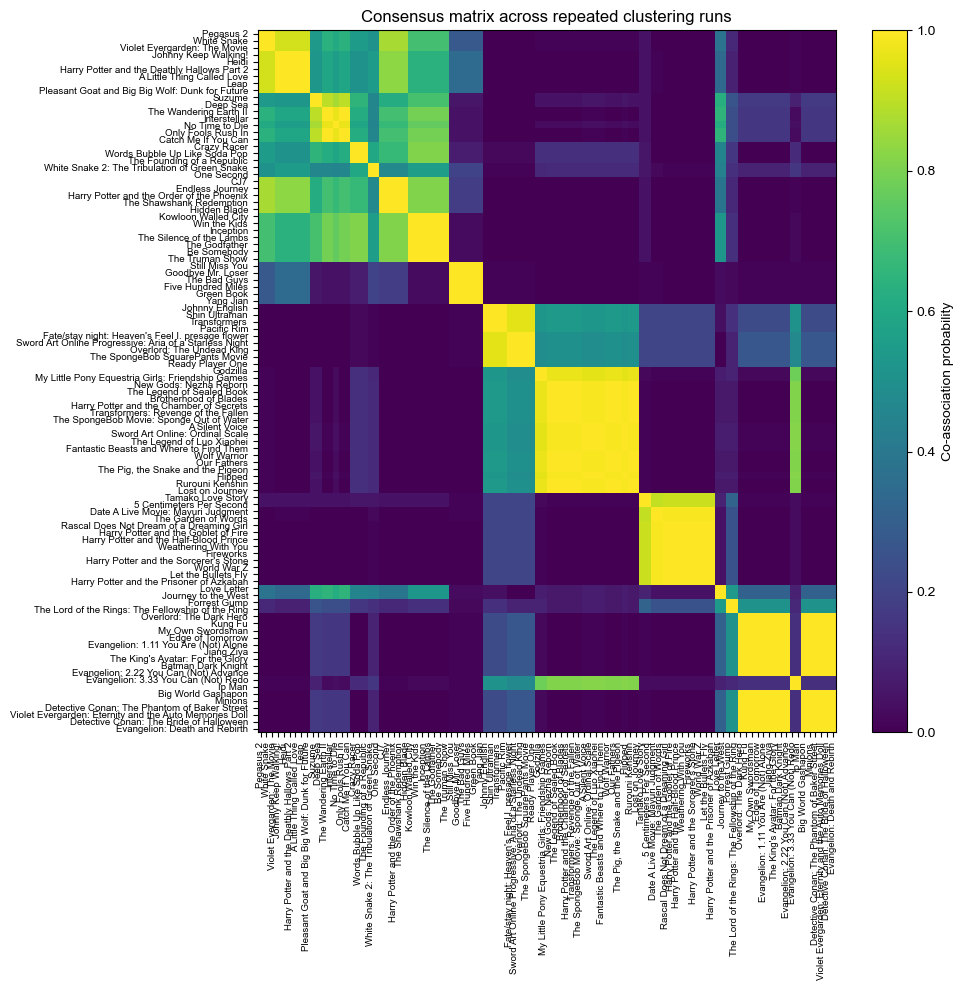

In [22]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

# 按 consensus clustering 的树排序
D = 1 - C
np.fill_diagonal(D, 0)
Z_consensus = linkage(squareform(D), method="average")

dendro = dendrogram(Z_consensus, no_plot=True)
ordered_names = [movie_names_eng[i] for i in order]

plt.figure(figsize=(10, 10))
plt.imshow(C[np.ix_(order, order)], vmin=0, vmax=1, aspect="auto")
plt.colorbar(label="Co-association probability")
plt.title("Consensus matrix across repeated clustering runs")
plt.xticks(range(len(order)), ordered_names, rotation=90, fontsize=7)
plt.yticks(range(len(order)), ordered_names, fontsize=7)
plt.tight_layout()
plt.show()

In [23]:
def summarize_consensus_clusters(C, consensus_ids, names, min_size=2):
    rows = []

    for cid in np.unique(consensus_ids):
        idx = np.where(consensus_ids == cid)[0]

        if len(idx) < min_size:
            continue

        subC = C[np.ix_(idx, idx)]

        # 去掉对角线，只看组内不同样本之间的共聚类概率
        off_diag = subC[np.triu_indices_from(subC, k=1)]

        rows.append({
            "consensus_cluster": cid,
            "size": len(idx),
            "mean_within_coassociation": off_diag.mean() if len(off_diag) > 0 else np.nan,
            "min_within_coassociation": off_diag.min() if len(off_diag) > 0 else np.nan,
            "max_within_coassociation": off_diag.max() if len(off_diag) > 0 else np.nan,
            "members": "; ".join([names[i] for i in idx]),
        })

    return pd.DataFrame(rows).sort_values(
        ["mean_within_coassociation", "size"],
        ascending=[False, False]
    )


cluster_summary = summarize_consensus_clusters(
    C,
    consensus_ids,
    movie_names_eng,
    min_size=2,
)

print(cluster_summary)
cluster_summary.to_csv("consensus_cluster_summary.csv", index=False)

    consensus_cluster  size  mean_within_coassociation  \
8                   9    15                   1.000000   
0                   1     6                   1.000000   
1                   2     2                   1.000000   
9                  10     2                   1.000000   
10                 11     2                   1.000000   
6                   7     9                   0.977778   
5                   6    13                   0.974615   
7                   8    20                   0.955421   
3                   4     7                   0.943810   
4                   5    10                   0.911333   
2                   3    14                   0.908681   

    min_within_coassociation  max_within_coassociation  \
8                       1.00                       1.0   
0                       1.00                       1.0   
1                       1.00                       1.0   
9                       1.00                       1.0   
10           

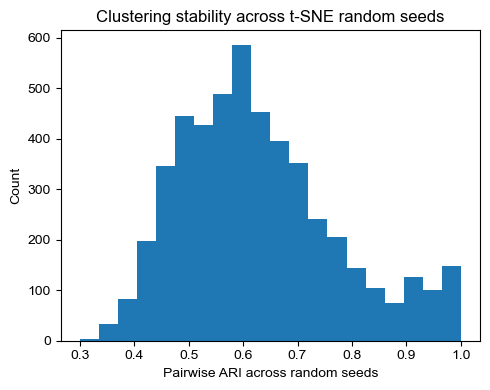

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
plt.hist(pairwise_result["ARI"], bins=20)
plt.xlabel("Pairwise ARI across random seeds")
plt.ylabel("Count")
plt.title("Clustering stability across t-SNE random seeds")
plt.tight_layout()
plt.show()

# baseline 聚类

In [25]:
# ---------- 原论文 baseline：不要重新跑 t-SNE ----------
Xs_base = X_embedded.copy()   # 这就是你论文图里用的二维坐标

Z_base = linkage(Xs_base, method="ward")

baseline_cluster_ids = fcluster(
    Z_base,
    t=color_threshold,
    criterion="distance"
)

print("Baseline cluster number:", len(np.unique(baseline_cluster_ids)))
print("Baseline cluster sizes:")
print(pd.Series(baseline_cluster_ids).value_counts().sort_index())

Baseline cluster number: 6
Baseline cluster sizes:
1     9
2    24
3     6
4    27
5    13
6    21
Name: count, dtype: int64


In [26]:
def run_repeat_tsne_hclust_by_threshold(
    data_concat,
    seed,
    perplexity=2,
    n_cluster=6,
    tsne_init="random",
    criterion="maxclust"
):
    X_rep = TSNE(
        n_components=2,
        learning_rate="auto",
        init=tsne_init,
        perplexity=perplexity,
        random_state=seed,
    ).fit_transform(data_concat)

    Z_rep = linkage(X_rep, method="ward")

    labels_rep = fcluster(
        Z_rep,
        t=n_cluster,
        criterion=criterion
    )

    return X_rep, Z_rep, labels_rep

In [27]:
def stability_against_existing_baseline(
    data_concat,
    movie_names_eng,
    X_embedded_baseline,
    baseline_cluster_ids,
    n_cluster=6,
    repeat_seeds=range(1, 101),
    perplexity=2,
    sample_stable_threshold=0.8,
):
    labels_base = np.asarray(baseline_cluster_ids)
    n_samples = len(labels_base)

    base_cluster_ids = np.unique(labels_base)

    base_clusters = {
        cid: np.where(labels_base == cid)[0]
        for cid in base_cluster_ids
    }

    global_records = []
    cluster_records = []
    sample_hit_count = np.zeros(n_samples, dtype=int)

    for seed in repeat_seeds:
        X_rep, Z_rep, labels_rep = run_repeat_tsne_hclust_by_threshold(
            data_concat=data_concat,
            seed=seed,
            perplexity=perplexity,
            n_cluster=n_cluster,
            tsne_init="random",
        )

        ari = adjusted_rand_score(labels_base, labels_rep)
        nmi = normalized_mutual_info_score(labels_base, labels_rep)

        global_records.append({
            "seed": seed,
            "ARI_vs_original_baseline": ari,
            "NMI_vs_original_baseline": nmi,
            "n_clusters_repeat": len(np.unique(labels_rep)),
        })

        rep_cluster_ids = np.unique(labels_rep)
        rep_clusters = {
            cid: np.where(labels_rep == cid)[0]
            for cid in rep_cluster_ids
        }

        for base_cid, base_members in base_clusters.items():
            base_set = set(base_members)

            best_rep_cid = None
            best_jaccard = -1
            best_overlap = np.array([], dtype=int)

            for rep_cid, rep_members in rep_clusters.items():
                rep_set = set(rep_members)

                inter = base_set & rep_set
                union = base_set | rep_set

                jaccard = len(inter) / len(union) if len(union) > 0 else np.nan

                if jaccard > best_jaccard:
                    best_jaccard = jaccard
                    best_rep_cid = rep_cid
                    best_overlap = np.array(sorted(list(inter)), dtype=int)

            sample_hit_count[best_overlap] += 1

            cluster_records.append({
                "seed": seed,
                "baseline_cluster": base_cid,
                "baseline_cluster_size": len(base_members),
                "best_matched_repeat_cluster": best_rep_cid,
                "best_jaccard": best_jaccard,
                "overlap_size": len(best_overlap),
                "recovery_rate": len(best_overlap) / len(base_members),
                "n_clusters_repeat": len(rep_cluster_ids),
            })

    global_df = pd.DataFrame(global_records)
    cluster_long_df = pd.DataFrame(cluster_records)

    global_summary = global_df[
        ["ARI_vs_original_baseline", "NMI_vs_original_baseline", "n_clusters_repeat"]
    ].agg(["mean", "std", "min", "median", "max"])

    cluster_summary = (
        cluster_long_df
        .groupby("baseline_cluster")
        .agg(
            baseline_cluster_size=("baseline_cluster_size", "first"),
            mean_jaccard=("best_jaccard", "mean"),
            std_jaccard=("best_jaccard", "std"),
            min_jaccard=("best_jaccard", "min"),
            median_jaccard=("best_jaccard", "median"),
            max_jaccard=("best_jaccard", "max"),
            mean_recovery_rate=("recovery_rate", "mean"),
            min_recovery_rate=("recovery_rate", "min"),
        )
        .reset_index()
        .sort_values("mean_jaccard", ascending=False)
    )

    members_list = []
    for cid in cluster_summary["baseline_cluster"]:
        idx = base_clusters[cid]
        members_list.append("; ".join([movie_names_eng[i] for i in idx]))

    cluster_summary["baseline_members"] = members_list

    n_repeats = len(list(repeat_seeds))
    sample_stability = sample_hit_count / n_repeats

    sample_df = pd.DataFrame({
        "sample_index": np.arange(n_samples),
        "movie_name": movie_names_eng,
        "baseline_cluster": labels_base,
        "sample_stability": sample_stability,
    })

    sample_df["stable_or_unstable"] = np.where(
        sample_df["sample_stability"] >= sample_stable_threshold,
        "stable",
        "unstable"
    )

    sample_df = sample_df.sort_values(
        ["baseline_cluster", "sample_stability"],
        ascending=[True, False]
    )

    return {
        "X_base": X_embedded_baseline,
        "Z_base": linkage(X_embedded_baseline, method="ward"),
        "labels_base": labels_base,
        "global_df": global_df,
        "global_summary": global_summary,
        "cluster_long_df": cluster_long_df,
        "cluster_summary": cluster_summary,
        "sample_df": sample_df,
    }

In [28]:
results_original = stability_against_existing_baseline(
    data_concat=data_concat,
    movie_names_eng=movie_names_eng,
    X_embedded_baseline=X_embedded,
    baseline_cluster_ids=baseline_cluster_ids,
    n_cluster=n_cluster,
    repeat_seeds=range(1, 101),
    perplexity=2,
    sample_stable_threshold=0.8,
)

print("整体稳定性：")
print(results_original["global_summary"])

print("\n原始每个簇的稳定性：")
print(results_original["cluster_summary"])

print("\n每个样本相对原始聚类的稳定性：")
print(results_original["sample_df"])

整体稳定性：
        ARI_vs_original_baseline  NMI_vs_original_baseline  n_clusters_repeat
mean                    0.622634                  0.758501                6.0
std                     0.100927                  0.061772                0.0
min                     0.408366                  0.602645                6.0
median                  0.611166                  0.751627                6.0
max                     0.910338                  0.924806                6.0

原始每个簇的稳定性：
   baseline_cluster  baseline_cluster_size  mean_jaccard  std_jaccard  \
4                 5                     13      0.906783     0.150339   
2                 3                      6      0.836606     0.260050   
5                 6                     21      0.717922     0.134130   
3                 4                     27      0.689924     0.159132   
1                 2                     24      0.622205     0.118888   
0                 1                      9      0.389180     0.142070   

 

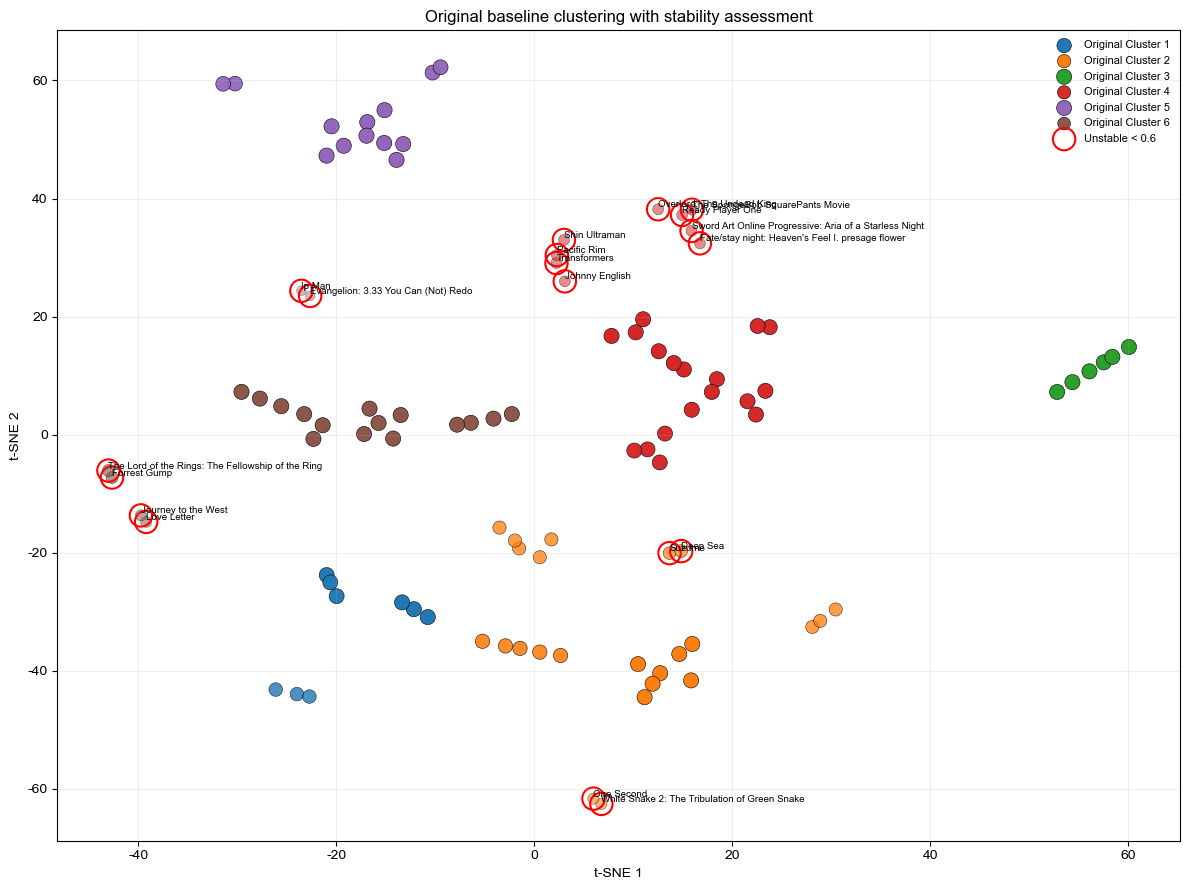

In [29]:
import matplotlib.pyplot as plt

def plot_original_baseline_with_stability(
    results,
    movie_names_eng,
    stability_threshold=0.8,
    figsize=(10, 8),
    annotate_unstable=True,
    save_path="original_baseline_cluster_stability.png",
):
    X_base = results["X_base"]
    labels_base = results["labels_base"]

    sample_df = results["sample_df"].copy()
    sample_df = sample_df.sort_values("sample_index").reset_index(drop=True)

    stability = sample_df["sample_stability"].values

    fig, ax = plt.subplots(figsize=figsize)

    for cid in np.unique(labels_base):
        idx = np.where(labels_base == cid)[0]

        ax.scatter(
            X_base[idx, 0],
            X_base[idx, 1],
            s=40 + 80 * stability[idx],
            alpha=0.35 + 0.65 * stability[idx],
            label=f"Original Cluster {cid}",
            edgecolors="black",
            linewidths=0.4,
        )

    unstable_idx = np.where(stability < stability_threshold)[0]

    ax.scatter(
        X_base[unstable_idx, 0],
        X_base[unstable_idx, 1],
        s=260,
        facecolors="none",
        edgecolors="red",
        linewidths=1.5,
        label=f"Unstable < {stability_threshold}",
    )

    if annotate_unstable:
        for i in unstable_idx:
            ax.text(
                X_base[i, 0],
                X_base[i, 1],
                movie_names_eng[i],
                fontsize=7,
                ha="left",
                va="bottom",
            )

    ax.set_title("Original baseline clustering with stability assessment")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(frameon=False, fontsize=8)
    ax.grid(alpha=0.2)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


plot_original_baseline_with_stability(
    results_original,
    movie_names_eng,
    stability_threshold=0.6,
    figsize=(12, 9),
    annotate_unstable=True,
    save_path="original_baseline_cluster_stability.png"
)

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.optimize import linear_sum_assignment


def run_repeat_tsne_hclust_by_threshold(
    data_concat,
    seed,
    perplexity=2,
    n_cluster=6,
    tsne_init="random",
    criterion="maxclust"
):
    X_rep = TSNE(
        n_components=2,
        learning_rate="auto",
        init=tsne_init,
        perplexity=perplexity,
        random_state=seed,
    ).fit_transform(data_concat)

    Z_rep = linkage(X_rep, method="ward")

    labels_rep = fcluster(
        Z_rep,
        t=n_cluster,
        criterion=criterion
    )
    
    
    return labels_rep


def align_repeat_labels_to_baseline(labels_base, labels_rep):
    """
    把一次重复聚类的 cluster label 对齐到 baseline cluster label。
    返回 aligned_labels_rep，里面的标签已经尽量对应 baseline 的簇编号。
    """
    labels_base = np.asarray(labels_base)
    labels_rep = np.asarray(labels_rep)

    base_ids = np.unique(labels_base)
    rep_ids = np.unique(labels_rep)

    overlap = np.zeros((len(base_ids), len(rep_ids)), dtype=int)

    for i, b in enumerate(base_ids):
        for j, r in enumerate(rep_ids):
            overlap[i, j] = np.sum((labels_base == b) & (labels_rep == r))

    # Hungarian algorithm：最大化 overlap
    row_ind, col_ind = linear_sum_assignment(-overlap)

    rep_to_base = {}
    for i, j in zip(row_ind, col_ind):
        rep_to_base[rep_ids[j]] = base_ids[i]

    # 没有匹配到的 repeat cluster 设为 -1
    aligned = np.array([
        rep_to_base.get(r, -1)
        for r in labels_rep
    ])

    return aligned, overlap, rep_to_base

In [31]:
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import adjusted_rand_score
import pandas as pd
import numpy as np

labels_threshold = fcluster(
    Z_base,
    t=color_threshold,
    criterion="distance"
)

labels_ncluster = fcluster(
    Z_base,
    t=6,
    criterion="maxclust"
)

print("threshold 切法的簇数:", len(np.unique(labels_threshold)))
print("n_clusters 切法的簇数:", len(np.unique(labels_ncluster)))

print("ARI between two baseline cuts:",
      adjusted_rand_score(labels_threshold, labels_ncluster))

ct = pd.crosstab(
    labels_threshold,
    labels_ncluster,
    rownames=["threshold=90"],
    colnames=["n_clusters=6"]
)

print(ct)

threshold 切法的簇数: 6
n_clusters 切法的簇数: 6
ARI between two baseline cuts: 1.0
n_clusters=6  1   2  3   4   5   6
threshold=90                      
1             9   0  0   0   0   0
2             0  24  0   0   0   0
3             0   0  6   0   0   0
4             0   0  0  27   0   0
5             0   0  0   0  13   0
6             0   0  0   0   0  21


In [32]:
# 原论文 baseline，不重新跑 t-SNE
Xs_base = X_embedded.copy()
Z_base = linkage(Xs_base, method="ward")

baseline_cluster_ids = fcluster(
    Z_base,
    t=6,
    criterion="maxclust"
)

print("Baseline cluster number:", len(np.unique(baseline_cluster_ids)))
print(pd.Series(baseline_cluster_ids).value_counts().sort_index())

Baseline cluster number: 6
1     9
2    24
3     6
4    27
5    13
6    21
Name: count, dtype: int64


In [33]:
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment


def align_repeat_labels_to_baseline_force(labels_base, labels_rep):
    """
    强制把 repeat 聚类标签一对一匹配到 baseline 标签。
    不产生 unmatched。
    """
    labels_base = np.asarray(labels_base)
    labels_rep = np.asarray(labels_rep)

    base_ids = np.unique(labels_base)
    rep_ids = np.unique(labels_rep)

    if len(base_ids) != len(rep_ids):
        raise ValueError(
            f"baseline has {len(base_ids)} clusters, "
            f"repeat has {len(rep_ids)} clusters. "
            "Cannot force one-to-one matching."
        )

    overlap = np.zeros((len(base_ids), len(rep_ids)), dtype=int)

    for i, b in enumerate(base_ids):
        for j, r in enumerate(rep_ids):
            overlap[i, j] = np.sum((labels_base == b) & (labels_rep == r))

    # 最大化 overlap
    row_ind, col_ind = linear_sum_assignment(-overlap)

    rep_to_base = {
        rep_ids[rj]: base_ids[bi]
        for bi, rj in zip(row_ind, col_ind)
    }

    aligned_rep = np.array([rep_to_base[r] for r in labels_rep])

    return aligned_rep, overlap, rep_to_base


def baseline_repeat_confusion_matrix(
    data_concat,
    labels_base,
    repeat_seeds=range(1, 101),
    perplexity=2,
    n_cluster=6,
):
    labels_base = np.asarray(labels_base)
    base_ids = np.unique(labels_base)

    if len(base_ids) != n_cluster:
        raise ValueError(
            f"labels_base has {len(base_ids)} clusters, but n_cluster={n_cluster}."
        )

    base_id_to_row = {cid: i for i, cid in enumerate(base_ids)}
    base_id_to_col = {cid: i for i, cid in enumerate(base_ids)}

    # 不再添加 Unmatched 列
    confusion_counts = np.zeros((len(base_ids), len(base_ids)), dtype=float)

    for seed in repeat_seeds:
        labels_rep = run_repeat_tsne_hclust_by_threshold(
            data_concat=data_concat,
            seed=seed,
            perplexity=perplexity,
            n_cluster=n_cluster,
            tsne_init="random",
            criterion="maxclust"
        )

        labels_rep = np.asarray(labels_rep)

        aligned_rep, overlap, rep_to_base = align_repeat_labels_to_baseline_force(
            labels_base,
            labels_rep
        )

        for b, r_aligned in zip(labels_base, aligned_rep):
            row = base_id_to_row[b]
            col = base_id_to_col[r_aligned]
            confusion_counts[row, col] += 1

    row_sums = confusion_counts.sum(axis=1, keepdims=True)
    confusion_prob = confusion_counts / row_sums

    # 原始 cluster id 反向显示：
    # 原始 1 -> Cluster 6
    # 原始 2 -> Cluster 5
    # ...
    # 原始 6 -> Cluster 1
    display_name = {cid: f"Cluster {n_cluster + 1 - cid}" for cid in base_ids}

    row_labels = [display_name[cid] for cid in base_ids]
    col_labels = [f"C{n_cluster + 1 - cid}" for cid in base_ids]

    confusion_df = pd.DataFrame(
        confusion_prob,
        index=row_labels,
        columns=col_labels
    )

    # 显示顺序改成 Cluster 1 到 Cluster 6
    row_order = [f"Cluster {i}" for i in range(1, n_cluster + 1)]
    col_order = [f"C{i}" for i in range(1, n_cluster + 1)]

    confusion_df = confusion_df.reindex(index=row_order, columns=col_order)

    return confusion_df, confusion_counts

In [34]:
confusion_df, confusion_counts = baseline_repeat_confusion_matrix(
    data_concat=data_concat,
    labels_base=baseline_cluster_ids,
    repeat_seeds=range(1, 101),
    perplexity=2,
    n_cluster=6,
)

confusion_df

,C1,C2,C3,C4,C5,C6
Cluster 1,0.788571,0.029524,0.084762,0.011429,0.034286,0.051429
Cluster 2,0.007692,0.980000,0.000000,0.003077,0.003077,0.006154
Cluster 3,0.061111,0.033333,0.751852,0.050370,0.002222,0.101111
Cluster 4,0.000000,0.000000,0.000000,0.840000,0.000000,0.160000
Cluster 5,0.033333,0.000000,0.035833,0.017500,0.745833,0.167500
Cluster 6,0.010000,0.003333,0.003333,0.010000,0.463333,0.510000


In [35]:
confusion_df.sort_values(by=confusion_df.columns.tolist(), ascending=False)
confusion_df = confusion_df.loc[
    [f"Cluster {i}" for i in range(1, 7)]
]
print(confusion_df)

                 C1        C2        C3        C4        C5        C6
Cluster 1  0.788571  0.029524  0.084762  0.011429  0.034286  0.051429
Cluster 2  0.007692  0.980000  0.000000  0.003077  0.003077  0.006154
Cluster 3  0.061111  0.033333  0.751852  0.050370  0.002222  0.101111
Cluster 4  0.000000  0.000000  0.000000  0.840000  0.000000  0.160000
Cluster 5  0.033333  0.000000  0.035833  0.017500  0.745833  0.167500
Cluster 6  0.010000  0.003333  0.003333  0.010000  0.463333  0.510000


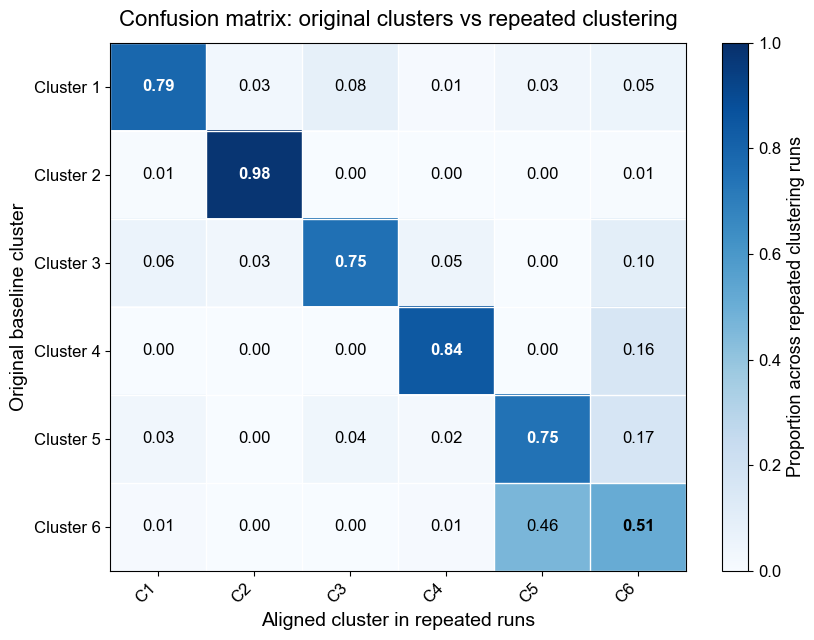

In [55]:
plot_cluster_confusion_matrix(
    confusion_df,
    figsize=(8.5, 6.5),
    save_path="baseline_repeat_confusion_matrix.png"
)

# 分析

In [38]:
cluster_name=[
    "Resonant Sadness",
    "Complex Flux",
    "Sustained Joy",
    "Neutral Action",
    "Poetic Surges",
    "Epic Escalations",
]

movie_names_eng = np.array(movie_names_eng)
cluster_ids = np.array(cluster_ids)

# 创建 one-hot
n_cluster = 6
onehot = np.zeros((len(cluster_ids), n_cluster), dtype=int)

for i, cid in enumerate(cluster_ids):
    # cluster id 从 1 开始
    if 1 <= cid <= n_cluster:
        onehot[i, cid-1] = 1

# 组合 dataframe
df = pd.DataFrame(onehot, columns=cluster_name)
df.insert(0, "Movie", movie_names_eng)

# 保存 CSV
df.to_csv("movie_6cluster_onehot.csv", index=False)

df.head()


,Movie,Resonant Sadness,Complex Flux,Sustained Joy,Neutral Action,Poetic Surges,Epic Escalations
0,Batman Dark Knight,0,0,0,0,0,1
1,Be Somebody,0,1,0,0,0,0
2,Forrest Gump,0,0,0,0,0,1
3,Big World Gashapon,0,0,0,0,0,1
4,Godzilla,0,0,0,1,0,0


In [39]:
import pandas as pd
import numpy as np

# ====== 文件路径 ======
old_path = r'/mnt/dataset1/xinke/Danmu/DyEmo-film/movie_genre_onehot.csv'  # 旧 102 部
new_path = 'movie_6cluster_onehot.csv'   # 现有 100 部 cluster mapping
save_path = 'movie_6cluster_onehot_aligned.csv'  # 输出新文件

# ====== 读取 ======
df_old = pd.read_csv(old_path)   # 102 movies
df_new = pd.read_csv(new_path)   # 100 movies

# ====== 取得电影名列 ======
old_names = df_old.iloc[:, 0].tolist()   # 旧 CSV 第一列
new_names = df_new.iloc[:, 0].tolist()   # 新 CSV 第一列（100）

# ====== 取得 cluster 列名（六类） ======
cluster_cols = df_new.columns[1:]   # 除电影名外剩下六列

# ====== 建立 new-name → onehot 映射 ======
map_new = {row[0]: row[1:].tolist() for _, row in df_new.iterrows()}

# ====== 构建新 onehot 表 ======
output = []

for name in old_names:
    if name in map_new:
        output.append(map_new[name])
    else:
        # 没有分类 → 六类填 0
        output.append([0]*len(cluster_cols))

output = np.array(output)

# ====== 汇总成 DF ======
df_out = pd.DataFrame(
    np.column_stack([old_names, output]),
    columns=["Movie Name"] + list(cluster_cols)
)

# cluster 列转为 int
for c in cluster_cols:
    df_out[c] = df_out[c].astype(int)

df_out.to_csv(save_path, index=False, encoding="utf-8-sig")
print(f"✅ Saved: {save_path}")
print(df_out.head())


✅ Saved: movie_6cluster_onehot_aligned.csv
           Movie Name  Resonant Sadness  Complex Flux  Sustained Joy  \
0  Batman Dark Knight                 0             0              0   
1         Be Somebody                 0             1              0   
2        Forrest Gump                 0             0              0   
3  Big World Gashapon                 0             0              0   
4            Godzilla                 0             0              0   

   Neutral Action  Poetic Surges  Epic Escalations  
0               0              0                 1  
1               0              0                 0  
2               0              0                 1  
3               0              0                 1  
4               1              0                 0  


/tmp/ipykernel_1372069/3708173376.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  map_new = {row[0]: row[1:].tolist() for _, row in df_new.iterrows()}


In [40]:
from scipy.cluster.hierarchy import dendrogram
from collections import Counter

# —— 先用不绘图的 dendrogram 拿到叶子颜色（与之前图保持一致）——
dendro_no_plot = dendrogram(
    Z, orientation='left', color_threshold=color_threshold,
    above_threshold_color='black', no_plot=True
)
leaf_colors_map = {leaf_idx: c
                   for leaf_idx, c in zip(dendro_no_plot['leaves'],
                                          dendro_no_plot['leaves_color_list'])}

# —— 计算每个簇的代表颜色：取该簇成员叶子颜色的众数 —— 
cluster_labels = np.unique(cluster_ids)
cluster_color_map = {}
for cid in cluster_labels:
    idx = np.where(cluster_ids == cid)[0]
    colors = [leaf_colors_map.get(i, 'black') for i in idx]
    cluster_color_map[cid] = Counter(colors).most_common(1)[0][0] if len(colors) else 'black'


In [41]:
cluster_name=[
    "Resonant Sadness",
    "Complex Flux",
    "Sustained Joy",
    "Balanced Action",
    "Poetic Surges",
    "Epic Escalations",
]


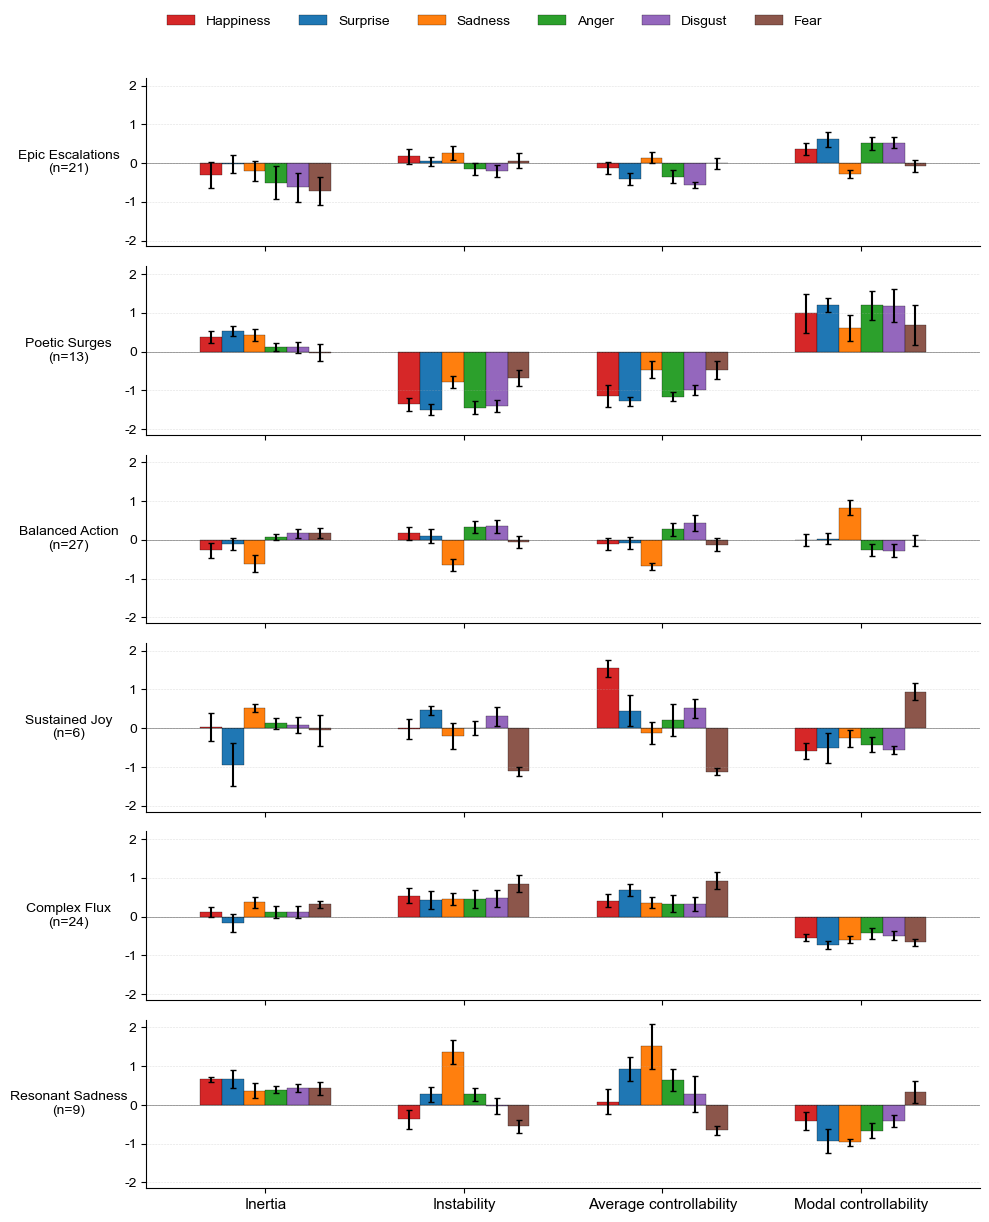

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# ==== 1) 仍然用你的聚类结果拿到 cluster_ids ====
Z = linkage(X_embedded, method='ward')
color_threshold = 90
cluster_ids = fcluster(Z, t=color_threshold, criterion='distance')  # shape=(n_samples,)

# ==== 2) 配置：情绪与“4个动力学特征”的列布局 ====
emotions = ['Happiness','Surprise','Sadness','Anger','Disgust','Fear']
block_names = ['Inertia','Instability','Average controllability','Modal controllability']
n_blocks = len(block_names)
n_emotions = len(emotions)
assert data_concat.shape[1] == n_blocks * n_emotions, \
    f"期望列数为 {n_blocks*n_emotions}，但拿到 {data_concat.shape[1]}。请确认列布局为 4个特征 × 6情绪"

# 预生成每个block的列索引（假设列顺序与热图一致：按 block 分组，每组内是 6个情绪）
block_cols = [
    list(range(b*n_emotions, (b+1)*n_emotions)) for b in range(n_blocks)
]

# ==== 3) 计算：每簇 × 每特征 × 每情绪 的均值 & 标准误 ====
cluster_labels = np.unique(cluster_ids)
n_clusters = len(cluster_labels)

means = np.zeros((n_clusters, n_blocks, n_emotions), dtype=float)
sems  = np.zeros((n_clusters, n_blocks, n_emotions), dtype=float)
sizes = np.zeros(n_clusters, dtype=int)

for ci, cid in enumerate(cluster_labels):
    idx = np.where(cluster_ids == cid)[0]
    sizes[ci] = len(idx)
    Xc = data_concat[idx]  # (n_in_cluster, 24)

    for b in range(n_blocks):
        cols = block_cols[b]
        block_data = Xc[:, cols]  # (n_in_cluster, 6)
        means[ci, b] = block_data.mean(axis=0)
        # 标准误：std/sqrt(n)
        sems[ci, b]  = block_data.std(axis=0, ddof=1) / np.sqrt(max(1, len(idx)))

# ==== 4) 画图：每个簇一行，x轴是4个特征，组内是6情绪的条形 ====
fig_h = max(2.0*n_clusters, 8)  # 高度随簇数自适应
fig, axes = plt.subplots(n_clusters, 1, figsize=(10, fig_h), sharex=True)
if n_clusters == 1:
    axes = [axes]

# 情绪图例配色（与你热图一致可自行替换）
emotion_colors = {
    'Happiness': '#d62728',  # red
    'Surprise' : '#1f77b4',  # blue
    'Sadness'  : '#ff7f0e',  # orange
    'Anger'    : '#2ca02c',  # green
    'Disgust'  : '#9467bd',  # purple
    'Fear'     : '#8c564b',  # gray
}

ecolors = [emotion_colors[e] for e in emotions]

bar_w = 0.11
x_centers = np.arange(n_blocks)  # 4个特征的位置

for ci, ax in enumerate(axes[::-1]):
    for ei, emo in enumerate(emotions):
        # 让6个情绪在每个特征中心左右错开
        offset = (ei - (n_emotions-1)/2) * bar_w
        ax.bar(x_centers + offset,
               means[ci, :, ei],
               width=bar_w,
               yerr=sems[ci, :, ei],
               capsize=2,
               label=emo if ci == 0 else None,   # 只在第一行放图例
               color=ecolors[ei],
               edgecolor='black',
               linewidth=0.2)
    # cid = cluster_labels[ci]
    # cname = cluster_name[ci]  # 或者 cluster_name[ci]，按你的变量名
    # ccolor = cluster_color_map.get(cid, 'black')

    # ax.set_ylabel(f'{cname}\n(n={sizes[ci]})',
    #               rotation=0, labelpad=40, va='center',
    #               color=ccolor)   # 关键：用簇色给名字上色
    ax.axhline(0, color='k', lw=0.6, alpha=0.4)
    ax.set_ylabel(f'{cluster_name[ci]}\n(n={sizes[ci]})', rotation=0, labelpad=40, va='center')
    ax.set_xlim(-0.6, n_blocks-0.4)
    ax.set_ylim(means.min()-0.65, means.max()+0.65)
    ax.grid(axis='y', ls='--', lw=0.4, alpha=0.4)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)


axes[-1].set_xticks(x_centers)
axes[-1].set_xticklabels(block_names, fontsize=11)

# 顶部图例
handles, labels_ = axes[-1].get_legend_handles_labels()
fig.tight_layout(rect=[0, 0, 1, 0.97])
leg = fig.legend(handles, labels_, ncol=6, loc='upper center', frameon=False, bbox_to_anchor=(0.5, 1.02))

plt.savefig('cluster_feature.jpg',dpi=300, bbox_inches='tight')

plt.show()


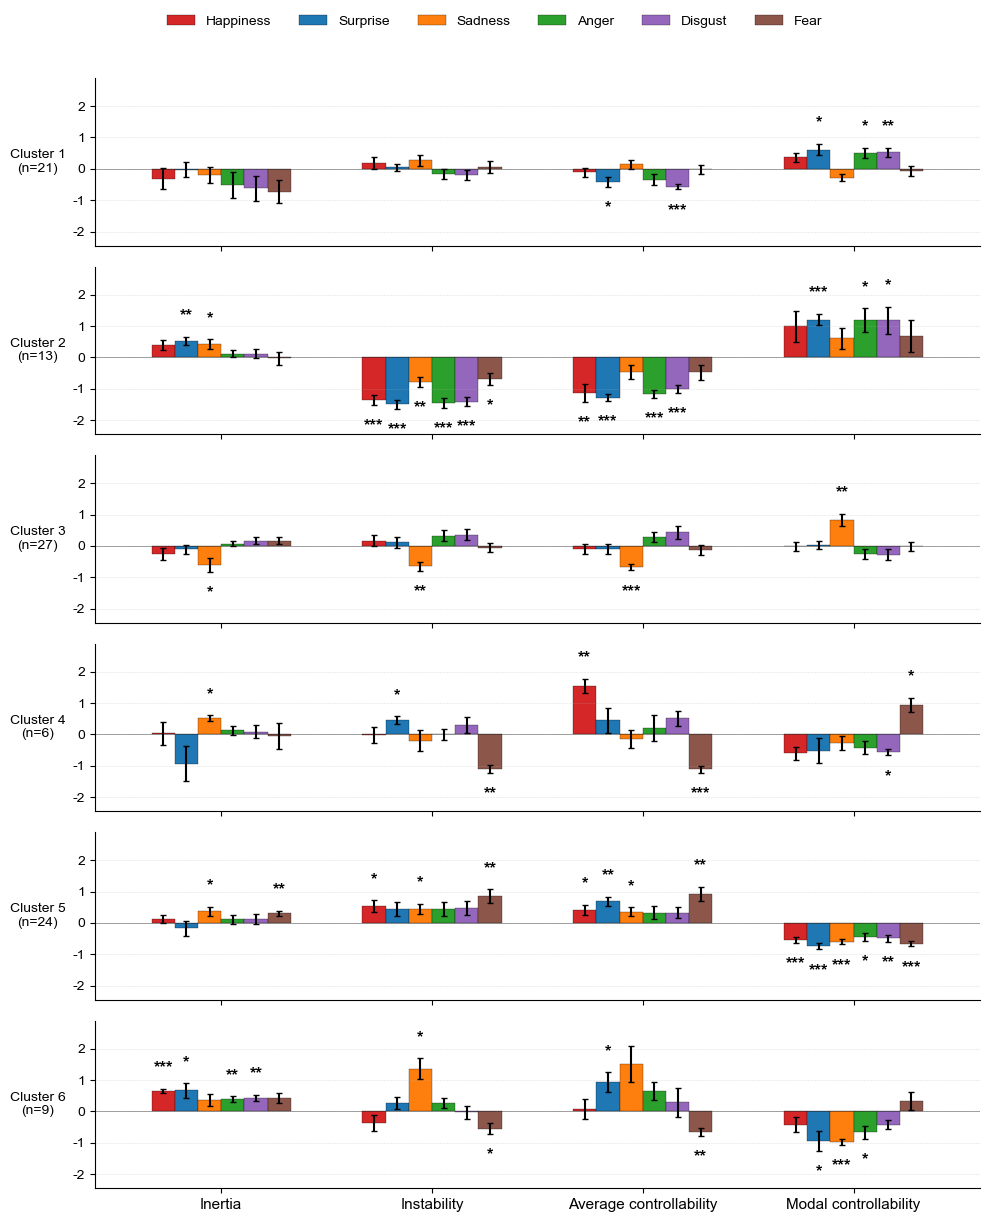

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy import stats
from statsmodels.stats.multitest import multipletests

# ==== 1) 仍然用你的聚类结果拿到 cluster_ids ====
Z = linkage(X_embedded, method='ward')
color_threshold = 90
cluster_ids = fcluster(Z, t=color_threshold, criterion='distance')  # shape=(n_samples,)

# ==== 2) 配置：情绪与“4个动力学特征”的列布局 ====
emotions = ['Happiness','Surprise','Sadness','Anger','Disgust','Fear']
block_names = ['Inertia','Instability','Average controllability','Modal controllability']
n_blocks = len(block_names)
n_emotions = len(emotions)

assert data_concat.shape[1] == n_blocks * n_emotions, \
    f"期望列数为 {n_blocks*n_emotions}，但拿到 {data_concat.shape[1]}。请确认列布局为 4个特征 × 6情绪"

# 预生成每个block的列索引（按 block 分组，每组内 6个情绪）
block_cols = [
    list(range(b*n_emotions, (b+1)*n_emotions)) for b in range(n_blocks)
]

# ==== 3) 计算：每簇 × 每特征 × 每情绪 的均值 & 标准误 ====
cluster_labels = np.unique(cluster_ids)
n_clusters = len(cluster_labels)

means = np.zeros((n_clusters, n_blocks, n_emotions), dtype=float)
sems  = np.zeros((n_clusters, n_blocks, n_emotions), dtype=float)
sizes = np.zeros(n_clusters, dtype=int)

for ci, cid in enumerate(cluster_labels):
    idx = np.where(cluster_ids == cid)[0]
    sizes[ci] = len(idx)
    Xc = data_concat[idx]  # (n_in_cluster, 24)

    for b in range(n_blocks):
        cols = block_cols[b]
        block_data = Xc[:, cols]  # (n_in_cluster, 6)
        means[ci, b] = np.nanmean(block_data, axis=0)
        if len(idx) > 1:
            sems[ci, b] = np.nanstd(block_data, axis=0, ddof=1) / np.sqrt(len(idx))
        else:
            sems[ci, b] = 0.0

# ==== 3.5) 显著性检验：单样本 t 检验 against 0 + FDR ====
pvals = np.full((n_clusters, n_blocks, n_emotions), np.nan)
tvals = np.full((n_clusters, n_blocks, n_emotions), np.nan)

for ci, cid in enumerate(cluster_labels):
    idx = np.where(cluster_ids == cid)[0]
    Xc = data_concat[idx]

    for b in range(n_blocks):
        cols = block_cols[b]
        for ei in range(n_emotions):
            vals = Xc[:, cols[ei]]
            vals = vals[np.isfinite(vals)]

            if len(vals) >= 2:
                t_stat, p_val = stats.ttest_1samp(vals, popmean=0.0, nan_policy='omit')
                tvals[ci, b, ei] = t_stat
                pvals[ci, b, ei] = p_val

# FDR(BH) 多重比较校正
valid_mask = np.isfinite(pvals)
pvals_flat = pvals[valid_mask]

sig_mask = np.zeros_like(pvals, dtype=bool)
qvals = np.full_like(pvals, np.nan, dtype=float)

if len(pvals_flat) > 0:
    reject, qvals_flat, _, _ = multipletests(pvals_flat, alpha=0.05, method='fdr_bh')
    sig_mask[valid_mask] = reject
    qvals[valid_mask] = qvals_flat

def stars_from_q(q):
    if not np.isfinite(q):
        return ''
    elif q < 0.001:
        return '***'
    elif q < 0.01:
        return '**'
    elif q < 0.05:
        return '*'
    else:
        return ''

# ==== 4) 画图：每个簇一行，x轴是4个特征，组内是6情绪的条形，并标注显著性 ====
fig_h = max(2.0*n_clusters, 8)
fig, axes = plt.subplots(n_clusters, 1, figsize=(10, fig_h), sharex=True)
if n_clusters == 1:
    axes = [axes]

emotion_colors = {
    'Happiness': '#d62728',  # red
    'Surprise' : '#1f77b4',  # blue
    'Sadness'  : '#ff7f0e',  # orange
    'Anger'    : '#2ca02c',  # green
    'Disgust'  : '#9467bd',  # purple
    'Fear'     : '#8c564b',  # brown
}
ecolors = [emotion_colors[e] for e in emotions]

bar_w = 0.11
x_centers = np.arange(n_blocks)

# 统一 y 轴范围，给显著性文字留空
ymin = np.nanmin(means - sems) - 0.8
ymax = np.nanmax(means + sems) + 0.8

# 文字偏移量
text_offset = 0.08 * (ymax - ymin)

for ci, ax in enumerate(axes[::-1]):   # 如果不想倒序显示，把 [::-1] 去掉
    for ei, emo in enumerate(emotions):
        offset = (ei - (n_emotions-1)/2) * bar_w
        x_pos = x_centers + offset

        ax.bar(
            x_pos,
            means[ci, :, ei],
            width=bar_w,
            yerr=sems[ci, :, ei],
            capsize=2,
            label=emo if ci == 0 else None,
            color=ecolors[ei],
            edgecolor='black',
            linewidth=0.2
        )

        # --- 给每个 bar 标显著性 ---
        for b in range(n_blocks):
            if sig_mask[ci, b, ei]:
                star = stars_from_q(qvals[ci, b, ei])
                m = means[ci, b, ei]
                s = sems[ci, b, ei]

                # 如果你想更明确区分方向，可改成：
                # txt = ('+' if m > 0 else '−') + star
                txt = star

                if m >= 0:
                    y_text = m + s + text_offset
                    va = 'bottom'
                else:
                    y_text = m - s - text_offset
                    va = 'top'

                ax.text(
                    x_pos[b],
                    y_text,
                    txt,
                    ha='center',
                    va=va,
                    fontsize=12,
                    fontweight='bold'
                )

    ax.axhline(0, color='k', lw=0.6, alpha=0.4)
    ax.set_ylabel(
        f'Cluster {6-ci}\n(n={sizes[ci]})',
        rotation=0, labelpad=25, va='center'
    )
    ax.set_xlim(-0.6, n_blocks-0.4)
    ax.set_ylim(ymin, ymax)
    ax.grid(axis='y', ls='--', lw=0.4, alpha=0.4)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

axes[-1].set_xticks(x_centers)
axes[-1].set_xticklabels(block_names, fontsize=11)

# 顶部图例
handles, labels_ = axes[-1].get_legend_handles_labels()
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.legend(handles, labels_, ncol=6, loc='upper center',
           frameon=False, bbox_to_anchor=(0.5, 1.02))

plt.savefig('cluster_feature_with_significance.jpg', dpi=300, bbox_inches='tight')
plt.show()